# Canada Food CPI — CFPR Replica Experiment

This notebook is a **methodology demonstration**: it shows what an agentic
forecasting pipeline looks like in practice, compares it to conventional
baselines on historical data, and — crucially — explains what those comparisons
can and cannot tell us.

**The leakage problem.** Frontier LLMs like Gemini were trained on data through
late 2024.  For most backtest origins here (2009–2024), the model has likely
been exposed to the resolved outcomes.  A strong CRPS score therefore tells us
the pipeline is working and the model can produce calibrated structured output
— it does not tell us the agent can genuinely forecast the future.  The right
interpretation is an **upper bound**: if a model with perfect recall of
historical outcomes scores X, a live deployment should aspire to approach X on
unresolved tasks.

Set `EXPERIMENT_CONFIG` in the config cell to choose the scope:
`mini_single` (1 target, 6 origins — default), `mini_recent` (9 targets, 6 origins),
or `full` (9 targets, 16 origins — canonical CFPR backtest).

**What's here:**

1. Data overview — nine food CPI sub-indices at a glance.
2. Spec + predictors — loaded from YAML; backtest results cached on disk.
3. Qualitative check — trajectory fans and avg/avg YoY grid.
4. Model selection — CRPS and MAPE per category.
5. What next — why live forecasting is the only clean evaluation.


---
## 1. Setup

The heavy lifting lives in helper modules alongside this notebook:

- `data.py`      registers the 9 StatCan series on a `DataService`.
- `analysis.py`  flattens results to DataFrames and computes avg/avg YoY.
- `plots.py`     renders the figures the CFPR audience expects.

Backtest specs (all under `reference_specs/food_cpi/`):

| Spec file | Tasks | Origins | Notes |
|---|---|---|---|
| `food_cpi_single_mini_backtest.yaml` | 1 (food overall) | 6 (2019–2024) | Fast dev/smoke-test |
| `food_cpi_recent_backtest.yaml` | 9 | 6 (2019–2024) | Recent regimes only |
| `food_cpi_cfpr_backtest.yaml` | 9 | 16 (2009–2024) | Canonical CFPR backtest |
| `food_cpi_cfpr_eval.yaml` | 9 | 4 (2021–2024) | Protected eval, `full` only |

Run the data fetch once if you haven't:

```bash
uv run python scripts/fetch_cpi.py
```


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parents[1]
load_dotenv(ROOT / ".env")

from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    cached_multi_backtest,
    describe_spec,
)
from aieng.forecasting.methods import DartsAutoARIMAPredictor, LastValuePredictor
from food_price_forecasting.analysis import compute_ape_long, compute_avgyoy, compute_mape, summarize_crps
from food_price_forecasting.data import CATEGORY_LABELS, build_food_cpi_service
from food_price_forecasting.plots import (
    plot_avgyoy_grid,
    plot_food_cpi_small_multiples,
    plot_mape_by_category,
    plot_trajectory_fan,
)


STATCAN_CACHE = ROOT / "data" / "statcan"
PREDICTIONS_DIR = ROOT / "data" / "predictions"
SPECS_DIR = ROOT / "reference_specs" / "food_cpi"

svc = build_food_cpi_service(cache_dir=STATCAN_CACHE)
print(f"Registered {len(CATEGORY_LABELS)} food CPI series.")

Registered 9 food CPI series.


In [2]:
# ── Experiment configuration ──────────────────────────────────────────────────
# Set EXPERIMENT_CONFIG to control which CFPR backtest runs throughout this
# notebook. All downstream cells adapt automatically.
#
#   "mini_single"  1 target (food overall) × 6 recent origins (Jul 2019–2024)
#                  ~6 agent calls — fastest; ideal for development / smoke test
#   "mini_recent"  9 targets × 6 recent origins (Jul 2019–2024)
#                  ~54 agent calls — covers COVID/inflation regimes
#   "full"         9 targets × 16 origins (Jul 2009–2024)
#                  ~144 agent calls — canonical CFPR backtest

EXPERIMENT_CONFIG = "mini_single"

_BACKTEST_SPEC_FILES = {
    "mini_single": "food_cpi_single_mini_backtest.yaml",
    "mini_recent": "food_cpi_recent_backtest.yaml",
    "full":        "food_cpi_cfpr_backtest.yaml",
}
_BACKTEST_SPEC_FILE = _BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]

print(f"Config: {EXPERIMENT_CONFIG!r}  →  {_BACKTEST_SPEC_FILE}")

Config: 'mini_single'  →  food_cpi_single_mini_backtest.yaml


---
## 2. Data exploration

A single figure is plenty — the nine sub-indices track each other closely with
a clear post-2020 acceleration.

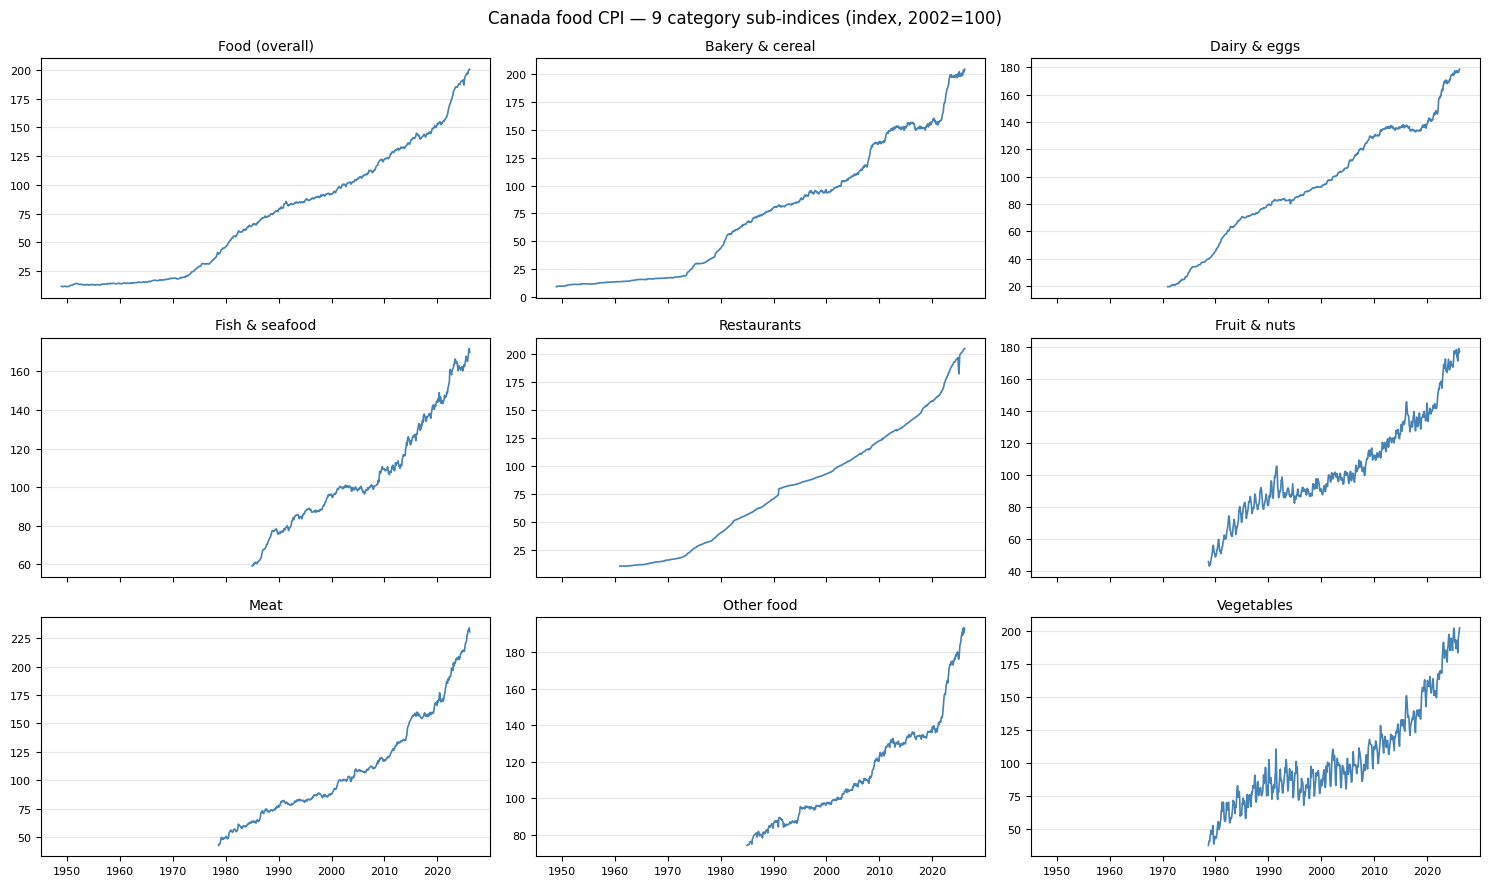

In [3]:
fig, _ = plot_food_cpi_small_multiples(svc)
plt.show()

---
## 3. The backtest spec

The backtest spec is loaded from YAML so the spec (not the notebook) is the
source of truth.  `describe_spec()` renders a plain-text summary suitable for
print, prompts, or documentation.

> **Training window note.** The `full` spec covers origins from July 2009 to
> July 2024.  Gemini's training data extends through late 2024, so virtually
> every origin in this spec — including the most recent ones — falls within the
> model's training window.  The model has plausibly been exposed to resolved
> inflation outcomes for all of these periods.  Keep this in mind when
> interpreting any LLM or agent scores below.

In [4]:
with (SPECS_DIR / _BACKTEST_SPEC_FILE).open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

print(describe_spec(backtest_spec, data_service=svc))
print(
    f"\nTasks: {len(backtest_spec.tasks)}  Window: {backtest_spec.start.date()} → {backtest_spec.end.date()}  Stride: {backtest_spec.stride}"
)

MultiTargetBacktestSpec (spec_id=food_cpi_single_mini_backtest)
  description: Single-target mini backtest: food CPI overall, 6 recent annual July origins (2019-2024), 12-step trajectory (horizons 6-17). Use for fast agent development and pipeline smoke-testing. Not budget-gated — run freely.
  start:       2019-07-01 00:00:00
  end:         2024-07-01 00:00:00
  stride:      12
  warmup:      24
  tasks:       1

Task: food_cpi_overall_cfpr
  description: Canada CPI Food (overall, 2002=100), trajectory across Jan-Dec of the year following a July origin.
  horizons:    [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] (len=12)
  frequency:   MS
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: cpi_food_canada
    description:    CPI Food (overall), Canada (2002=100)
    source:         Statistics Canada
    units:          Index 2002=100
    frequency:      MS


Tasks: 1  Window: 2019-07-01 → 2024-07-01  Stride: 12


---
## 4. Predictors

Eight predictors across four groups, each implementing the same `Predictor`
API against the configured backtest spec.  Swap in your own subclass or add
to `all_predictors` to run it through the full evaluation loop.

| Group | Predictor | Notes |
|---|---|---|
| Baselines | `LastValuePredictor` | Repeats last observed value; hard to beat at short horizons. |
| Baselines | `DartsAutoARIMAPredictor` | Auto-ARIMA via Darts; fits at each origin. |
| LLMP ×2 | `ContinuousLLMPredictor` | Direct LLM call; structured JSON trajectory; no tools or search. |
| Agent ×2 (search off) | `AgentPredictor` | ADK agent with food CPI instruction; historical-backtest-safe. |
| Agent ×2 (search on) | `AgentPredictor` | Same agent with `context_agent` (bounded Google Search) enabled. |

### Agent configuration: identity vs. role

`AgentConfig` captures the agent's **identity** — instruction, model, capability
toggles.  `AgentPredictor` captures the agent's **role** — which output schema
it must satisfy in this experiment.  The same config can be reused across roles.

**One-liner (default settings):**

```python
predictor = build_food_price_agent_predictor(model="gemini-3-flash-preview")
```

**Explicit construction (shows the identity/role split):**

```python
from aieng.forecasting.methods.agentic import AgentPredictor, ContinuousAgentForecastOutput
from food_price_forecasting.analyst_agent import (
    FoodPriceForecastPromptBuilder,
    build_food_price_agent_config,
)

config = build_food_price_agent_config(model="gemini-3-flash-preview")  # identity
predictor = AgentPredictor(                                              # role
    config,
    FoodPriceForecastPromptBuilder(),
    output_schema=ContinuousAgentForecastOutput,
)
```

### Leakage — two layers

**Layer 1: the search tool.**  `enable_news_search=True` attaches a
`context_agent` tool — a bounded Google Search sub-agent whose instruction
asks it to restrict evidence to sources published before `as_of`.  This is
a soft, model-enforced filter, not a technical guarantee.  Including both
search-on and search-off predictors lets us measure the tool's effect on
calibration independently of the deeper issue below.

**Layer 2: model weights.**  Even with search disabled, a frontier LLM is
not a blank slate.  The model weights encode a compressed representation of
its training corpus — which, for Gemini, includes news, statistics, and
economic commentary up to late 2024.  For a July 2021 origin, the model
implicitly "knows" that food inflation spiked in 2022.  This is not a bug
that can be filtered away; it is structural.  The agent and LLMP predictors
are therefore not producing genuine out-of-sample forecasts for these
historical origins — they are producing calibrated reconstructions of an
outcome the model has already, in some sense, seen.

This is why a side-by-side comparison with ARIMA on a historical backtest is
not a fair contest.  ARIMA has no access to future information; the LLM does.
The right framing is: **the agent backtest score is an approximate upper bound**
on what you might expect from a live deployment on unresolved tasks.

### Smoke test

The next cell runs a single `predict()` call as a pre-flight check before the
full backtest.  If `LANGFUSE_PUBLIC_KEY` / `LANGFUSE_SECRET_KEY` are set in
`.env`, a trace URL is printed — useful for inspecting tool calls
(`context_agent`, `set_model_response`) and the structured output.


In [5]:
import pandas as pd
from aieng.forecasting.methods import ContinuousLLMPredictor, ContinuousLLMPredictorConfig
from food_price_forecasting.analyst_agent import build_food_price_agent_predictor

# ── Baselines ─────────────────────────────────────────────────────────────────
lv = LastValuePredictor()
arima = DartsAutoARIMAPredictor()

# ── LLM predictors (direct structured output, no tools) ───────────────────────
llmp_flash3 = ContinuousLLMPredictor(
    ContinuousLLMPredictorConfig(model="gemini/gemini-3-flash-preview", n_samples=3)
)
llmp_flash3_5 = ContinuousLLMPredictor(
    ContinuousLLMPredictorConfig(model="gemini/gemini-3.5-flash", n_samples=3)
)

# ── Agent predictors — news search OFF (safe for historical backtests) ─────────
agent_flash3 = build_food_price_agent_predictor(
    model="gemini-3-flash-preview", enable_news_search=False
)
agent_flash3_5 = build_food_price_agent_predictor(
    model="gemini-3.5-flash", enable_news_search=False
)

# ── Agent predictors — news search ON (leakage risk on historical as_of dates) ─
agent_flash3_search = build_food_price_agent_predictor(
    model="gemini-3-flash-preview", enable_news_search=True
)
agent_flash3_5_search = build_food_price_agent_predictor(
    model="gemini-3.5-flash", enable_news_search=True
)

all_predictors = [
    lv, arima,
    llmp_flash3, llmp_flash3_5,
    agent_flash3, agent_flash3_5,
    agent_flash3_search, agent_flash3_5_search,
]

# Colors: gray/blue = baselines, red = LLMP, orange = agent no-search, green = agent search
PREDICTOR_COLORS: dict[str, str] = {
    lv.predictor_id:                    "#7f7f7f",
    arima.predictor_id:                 "#1f77b4",
    llmp_flash3.predictor_id:           "#d62728",
    llmp_flash3_5.predictor_id:         "#e87070",
    agent_flash3.predictor_id:          "#ff7f0e",
    agent_flash3_5.predictor_id:        "#ffb347",
    agent_flash3_search.predictor_id:   "#2ca02c",
    agent_flash3_5_search.predictor_id: "#72c472",
}

for p in all_predictors:
    print(f"  {p.predictor_id}")


  last_value_naive
  darts_autoarima
  llmp_continuous[gemini/gemini-3-flash-preview]
  llmp_continuous[gemini/gemini-3.5-flash]
  agent_predictor_food_price_forecasting_agent_gemini-3-flash-preview_continuous
  agent_predictor_food_price_forecasting_agent_gemini-3.5-flash_continuous
  agent_predictor_food_price_forecasting_agent_gemini-3-flash-preview_continuous
  agent_predictor_food_price_forecasting_agent_gemini-3.5-flash_continuous


In [6]:
# Agent smoke test — shows the exact inputs sent to the model, runs one
# predict() call, validates the structured output, and prints a trace link.
# Requires GEMINI_API_KEY.  Langfuse keys optional.

# ── Suppress third-party infrastructure noise ─────────────────────────────────
# OpenTelemetry context teardown, asyncio task cleanup, and ADK response-part
# warnings are all benign artefacts of running ADK's async runner inside a
# synchronous Jupyter cell.  They obscure the educational output without adding
# signal, so we silence them here.
import logging, warnings
warnings.filterwarnings("ignore")
for _noisy_log in ["opentelemetry", "openinference", "asyncio", "langfuse", "google.adk"]:
    logging.getLogger(_noisy_log).setLevel(logging.ERROR)
logging.basicConfig(level=logging.WARNING, format="%(message)s")

# ── Imports ───────────────────────────────────────────────────────────────────
from datetime import datetime

from aieng.forecasting.evaluation.task import ForecastingTask
from aieng.forecasting.langfuse_tracing import init_langfuse_tracing, print_langfuse_trace_url
from food_price_forecasting.analyst_agent import FoodPriceForecastPromptBuilder, build_food_price_agent_predictor
from food_price_forecasting.data import build_food_cpi_service
from food_price_forecasting.smoke_report import CFPR_HORIZONS, summarize_agent_predictions
from pydantic import ValidationError

init_langfuse_tracing()

# ── Task + predictor ──────────────────────────────────────────────────────────
_AGENT_SMOKE_ORIGIN = datetime(2023, 7, 1)
_AGENT_SMOKE_TASK = ForecastingTask(
    task_id="meat_cfpr",
    target_series_id="cpi_meat_canada",
    horizons=CFPR_HORIZONS,
    frequency="MS",
    description="Meat CFPR; Jan–Dec trajectory from July origin.",
)

ENABLE_NEWS_SEARCH_SMOKE = True  # set False to skip news search (faster, no leakage risk)

_smoke_svc = build_food_cpi_service(cache_dir=STATCAN_CACHE)
_smoke_predictor = build_food_price_agent_predictor(
    model="gemini-3.5-flash",
    enable_news_search=ENABLE_NEWS_SEARCH_SMOKE,
    prompt_builder=FoodPriceForecastPromptBuilder(max_history_rows=60),
)
_ctx = _smoke_svc.context(as_of=_AGENT_SMOKE_ORIGIN)

# ── Show inputs ───────────────────────────────────────────────────────────────
_user_msg = _smoke_predictor.prompt_builder(task=_AGENT_SMOKE_TASK, context=_ctx)

print("━" * 72)
print("SYSTEM PROMPT")
print("━" * 72)
print(_smoke_predictor.agent_config.instruction)

print()
print("━" * 72)
print("USER MESSAGE  (built from task + context for this origin)")
print("━" * 72)
print(_user_msg)

print()
print(f"model: gemini-3.5-flash  |  context_agent: {'enabled' if ENABLE_NEWS_SEARCH_SMOKE else 'disabled'}")
print("Running predict() ...\n")

# ── Run + validate ────────────────────────────────────────────────────────────
try:
    _smoke_preds = _smoke_predictor.predict(_AGENT_SMOKE_TASK, _ctx)
except ValidationError:
    print("✗ SCHEMA VALIDATION FAILED — model response did not match structured output schema.")
    _smoke_preds = []

summarize_agent_predictions(_smoke_preds, expected_horizons=CFPR_HORIZONS)
print_langfuse_trace_url()  # flushes Langfuse spans; prints trace URL if keys are configured

smoke predictor: context_agent=enabled


/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/authlib/_joserfc_helpers.py:8: AuthlibDeprecationWarning: authlib.jose module is deprecated, please use joserfc instead.
It will be compatible before version 2.0.0.
  from authlib.jose import ECKey
Task was destroyed but it is pending!
task: <Task pending name='Task-62' coro=<<async_generator_athrow without __name__>()>>
Failed to detach context
Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/trace/__init__.py", line 589, in use_span
    yield span
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/openinference/instrumentation/_tracers.py", line 141, in start_as_current_span
    yield cast(OpenInferenceSpan, current_span)
GeneratorExit

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/p


✓ Well-formed fan: 12 predictions (horizons 6–17)

     Month     Point       q05       q50       q95  OK
    ──────     ─────       ───       ───       ───  ──
   2024-01    208.50    198.50    208.50    218.50  ok
   2024-02    207.50    196.80    207.50    218.20  ok
   2024-03    207.70    196.40    207.70    219.10  ok
   2024-04    209.40    197.40    209.40    221.40  ok
   2024-05    210.40    197.70    210.40    223.10  ok
   2024-06    211.70    198.40    211.70    225.00  ok
   2024-07    213.20    199.20    213.20    227.20  ok
   2024-08    213.00    198.50    213.00    227.50  ok
   2024-09    213.90    198.90    213.90    228.90  ok
   2024-10    213.90    198.40    213.90    229.40  ok
   2024-11    214.10    198.10    214.10    230.10  ok
   2024-12    213.20    196.80    213.20    229.70  ok

  Rationale:
    To generate a calibrated continuous forecast for the Canadian Meat CPI
    (cpi_meat_canada) from the July 2023 origin to January-December 2024
    (horizons 6 

Context error: No active span in current context. Operations that depend on an active span will be skipped. Ensure spans are created with start_as_current_observation() or that you're operating within an active span context.
Context error: No active span in current context. Operations that depend on an active span will be skipped. Ensure spans are created with start_as_current_observation() or that you're operating within an active span context.


Langfuse: trace id not available in this process after flush.
  Open traces: https://us.cloud.langfuse.com/project/cmobssx3g00buad07gb4o1gh6/traces


---
## 5. Backtest (cached on disk)

`cached_multi_backtest` writes each `BacktestResult` to
`data/predictions/<spec_id>/<predictor_id>/<task_id>.yaml` and reuses it on
subsequent runs.  Pass `force_refresh=True` to re-run a predictor from scratch.

All predictors run against the configured backtest spec (set in the config cell above).
`ContinuousLLMPredictor` and the agent predictor make API calls on a first run
(~6 / ~54 / ~144 calls for `mini_single` / `mini_recent` / `full` respectively);
subsequent runs are free from cache.

**What this backtest is measuring:**

| What we learn | What we don't learn |
|---|---|
| The pipeline runs end-to-end without errors | Whether the agent can forecast genuinely unseen data |
| The model produces valid calibrated structured output | Whether strong scores reflect skill or memorization |
| An approximate upper bound on live performance | How the agent performs when the future is actually unknown |

Think of it this way: a human expert who had already read the outcome would
also beat ARIMA.  The interesting question — whether the agent provides useful
calibrated uncertainty when the future is genuinely open — can only be answered
by forecasting tasks that haven't resolved yet.


In [7]:
results_by_predictor: dict[str, dict[str, object]] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor,
        spec=backtest_spec,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:42s}  mean CRPS = {result.mean_crps:.4f}  ({len(result.predictions)} preds)")

Running last_value_naive ...
  food_cpi_overall_cfpr                       mean CRPS = 7.4208  (72 preds)
Running darts_autoarima ...
  food_cpi_overall_cfpr                       mean CRPS = 4.3387  (72 preds)
Running llmp_continuous[gemini/gemini-3-flash-preview] ...
  food_cpi_overall_cfpr                       mean CRPS = 1.7602  (72 preds)
Running llmp_continuous[gemini/gemini-3.5-flash] ...
  food_cpi_overall_cfpr                       mean CRPS = 1.9491  (72 preds)
Running agent_predictor_food_price_forecasting_agent_gemini-3-flash-preview_continuous ...


Task was destroyed but it is pending!
task: <Task pending name='Task-71' coro=<<async_generator_athrow without __name__>()>>
Failed to detach context
Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/trace/__init__.py", line 589, in use_span
    yield span
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/openinference/instrumentation/_tracers.py", line 141, in start_as_current_span
    yield cast(OpenInferenceSpan, current_span)
GeneratorExit

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/context/__init__.py", line 155, in detach
    _RUNTIME_CONTEXT.detach(token)
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/context/contextvars_context.py", line 53, in detach
    self.

  food_cpi_overall_cfpr                       mean CRPS = 2.2728  (72 preds)
Running agent_predictor_food_price_forecasting_agent_gemini-3.5-flash_continuous ...


Task was destroyed but it is pending!
task: <Task pending name='Task-107' coro=<<async_generator_athrow without __name__>()>>
Failed to detach context
Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/trace/__init__.py", line 589, in use_span
    yield span
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/openinference/instrumentation/_tracers.py", line 141, in start_as_current_span
    yield cast(OpenInferenceSpan, current_span)
GeneratorExit

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/context/__init__.py", line 155, in detach
    _RUNTIME_CONTEXT.detach(token)
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/context/contextvars_context.py", line 53, in detach
    self

  food_cpi_overall_cfpr                       mean CRPS = 1.6104  (72 preds)
Running agent_predictor_food_price_forecasting_agent_gemini-3-flash-preview_continuous ...
  food_cpi_overall_cfpr                       mean CRPS = 2.2728  (72 preds)
Running agent_predictor_food_price_forecasting_agent_gemini-3.5-flash_continuous ...
  food_cpi_overall_cfpr                       mean CRPS = 1.6104  (72 preds)


---
## 6. Trajectories — focal series

Show the three most recent origins for the focal series (`FOCAL_TASK`, derived
from the first task in the backtest spec) with each predictor's 12-step
trajectory fan.  Solid black is observed history, dashed black is Y+1 actuals
where available, fans are the predictor's 90%/50% intervals with the median in
colour.

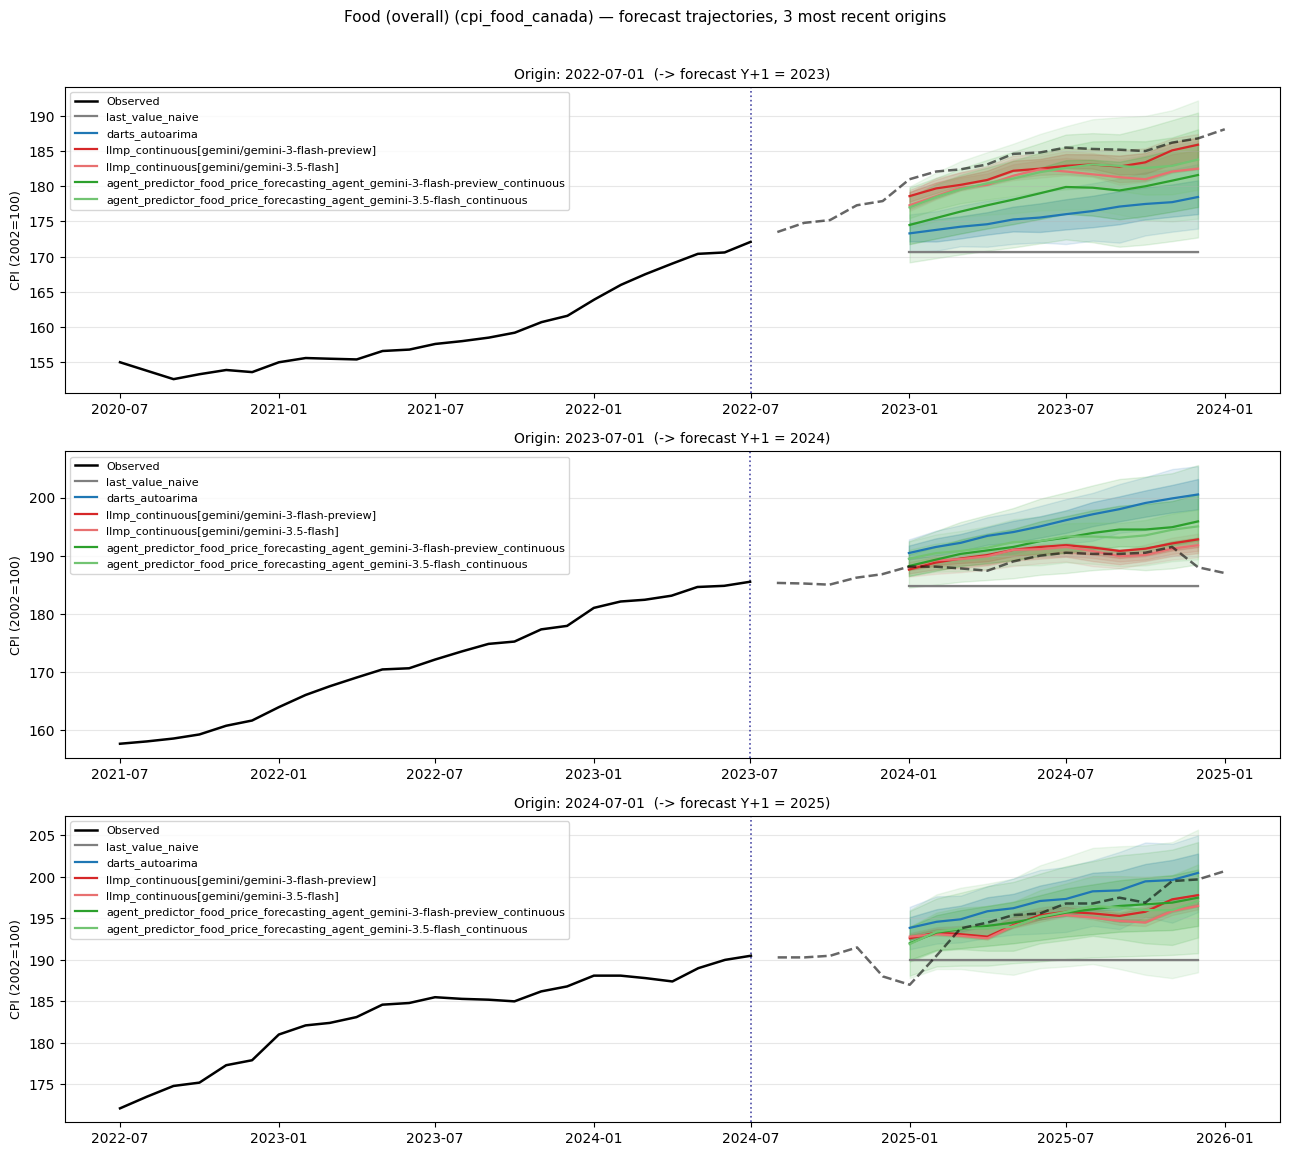

In [8]:
# Derive from the first task in the loaded spec so this adapts to any config.
FOCAL_TASK = backtest_spec.tasks[0].task_id
FOCAL_SERIES = backtest_spec.tasks[0].target_series_id

fig, _ = plot_trajectory_fan(
    results_by_predictor=results_by_predictor,
    task_id=FOCAL_TASK,
    category_id=FOCAL_SERIES,
    data_service=svc,
    n_recent=3,
    colors=PREDICTOR_COLORS,
)
plt.show()

---
## 7. Avg/avg YoY — food CPI categories

The headline CFPR metric: for each July origin, mean predicted CPI for year Y+1
divided by mean observed CPI for year Y, minus 1.  Actual realised YoY (solid
black) is the out-of-sample truth for every completed year.

**Note on the 2022 spike:** LLMP with `reasoning_effort="disable"` anchors its
extrapolation on the *current level* rather than the *rate of change*, so it
tends to underestimate carry-through during a mid-surge origin.  This is a
known limitation of level-domain direct prompting (Gruver / CiK), not a
data-feeding issue.


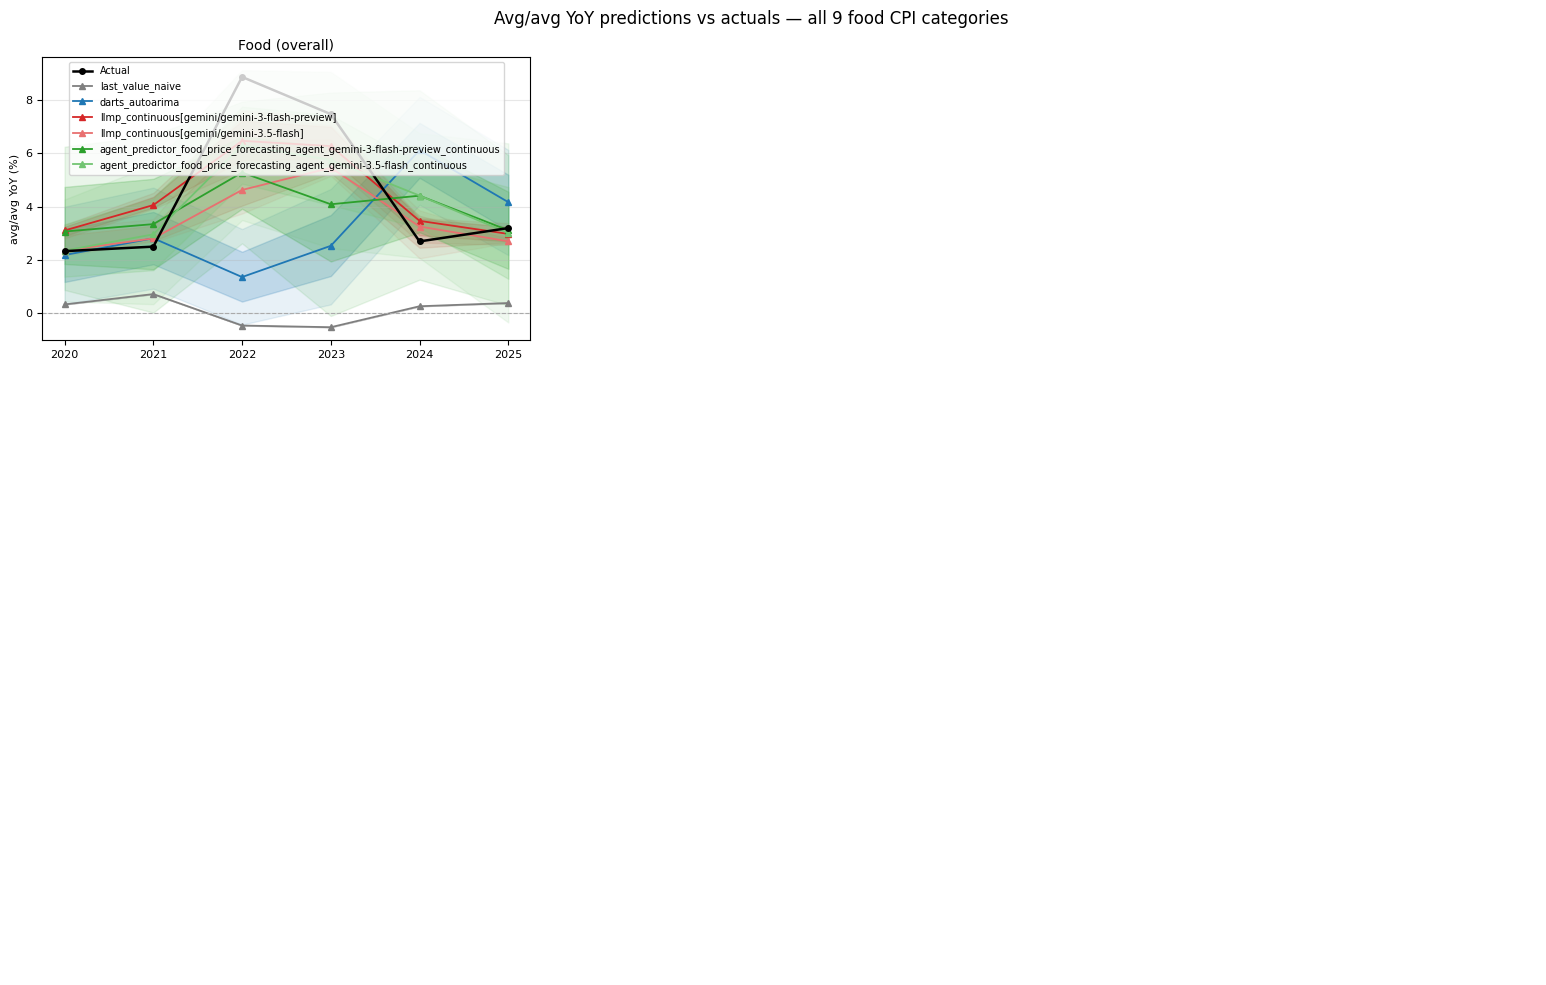

In [9]:
from datetime import datetime, timezone


yoy_by_predictor_by_task: dict[str, dict[str, object]] = {}
task_to_category: dict[str, str] = {task.task_id: task.target_series_id for task in backtest_spec.tasks}

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)

for pid, task_results in results_by_predictor.items():
    yoy_by_predictor_by_task[pid] = {}
    for task_id, result in task_results.items():
        actual_df = svc.get_series(result.spec.task.target_series_id, as_of=_as_of)
        yoy_by_predictor_by_task[pid][task_id] = compute_avgyoy(result, actual_df)

fig, _ = plot_avgyoy_grid(
    yoy_by_predictor_by_task=yoy_by_predictor_by_task,
    task_to_category=task_to_category,
    colors=PREDICTOR_COLORS,
)
plt.show()

---
## 8. Model selection

A note on interpreting scores for LLM-based predictors: because these backtest
origins are within the training window of frontier models, low CRPS values
reflect a combination of (a) genuine calibration quality and (b) the model
"recalling" outcomes it has implicitly seen.  These two contributions cannot be
separated from the backtest alone.  Use the scores to confirm the pipeline is
working and to establish a performance ceiling, not to draw conclusions about
live predictive skill.

### 8.1 CRPS per category

Lower is better.  The `MEAN` row is the across-category average — useful
context, but the per-category rows are the basis for model selection.

In [10]:
crps_board = summarize_crps(results_by_predictor)
print(crps_board.to_string())

predictor_id           agent_predictor_food_price_forecasting_agent_gemini-3-flash-preview_continuous  agent_predictor_food_price_forecasting_agent_gemini-3.5-flash_continuous  darts_autoarima  last_value_naive  llmp_continuous[gemini/gemini-3-flash-preview]  llmp_continuous[gemini/gemini-3.5-flash]
task_id                                                                                                                                                                                                                                                                                                     
food_cpi_overall_cfpr                                                                          2.2728                                                                    1.6104           4.3387            7.4208                                          1.7602                                    1.9491
MEAN                                                                                           2.

### 8.2 MAPE per category

Median-accuracy sanity check (CRPS is the primary selection metric).  One panel
per sub-index; each box spans the distribution of per-prediction absolute
percentage errors across all backtest origins and horizons.

predictor_id           agent_predictor_food_price_forecasting_agent_gemini-3-flash-preview_continuous  agent_predictor_food_price_forecasting_agent_gemini-3.5-flash_continuous  darts_autoarima  last_value_naive  llmp_continuous[gemini/gemini-3-flash-preview]  llmp_continuous[gemini/gemini-3.5-flash]
task_id                                                                                                                                                                                                                                                                                                     
food_cpi_overall_cfpr                                                                           1.793                                                                     1.317            2.849             4.163                                           1.245                                     1.499


AttributeError: 'numpy.ndarray' object has no attribute 'boxplot'

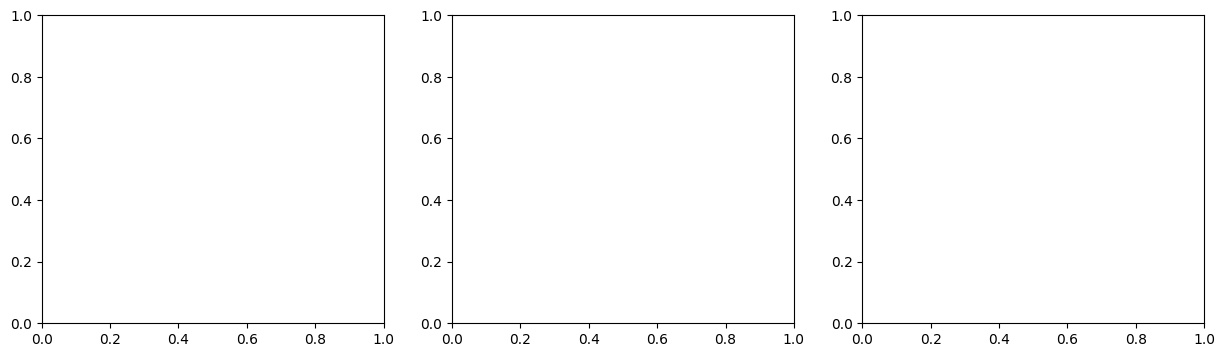

In [11]:
mape_df = compute_mape(results_by_predictor, data_service=svc)
print(mape_df.to_string())

ape_long = compute_ape_long(results_by_predictor, data_service=svc)
fig, _ = plot_mape_by_category(ape_long, task_to_category=task_to_category, colors=PREDICTOR_COLORS)
plt.show()

---
## 9. Backtest-average avg/avg YoY — headline table

Model selection is done **per category**: for each food CPI sub-index the
predictor with the lowest mean CRPS over all backtest origins and horizons for
that category is selected independently.  The table below shows each
category's best predictor and its avg/avg YoY central estimate and uncertainty
band averaged across the full backtest window.

In [ ]:
# Best predictor per category, selected by that category's own mean CRPS.
best_pid_by_task: dict[str, str] = crps_board.drop(index="MEAN").idxmin(axis=1).to_dict()
print("Best predictor by category (mean CRPS over full backtest window):")
for task_id, pid in best_pid_by_task.items():
    category = CATEGORY_LABELS.get(task_to_category[task_id], task_id)
    print(f"  {category:<40s} {pid}")

rows: list[dict[str, object]] = []
for task_id, pid in best_pid_by_task.items():
    yoy_df = yoy_by_predictor_by_task[pid].get(task_id)
    if yoy_df is None or yoy_df.empty:
        continue
    avg = yoy_df[["yoy_median", "yoy_q05", "yoy_q25", "yoy_q75", "yoy_q95", "actual_yoy"]].mean()
    rows.append(
        {
            "category": CATEGORY_LABELS.get(task_to_category[task_id], task_id),
            "best_predictor": pid,
            "median_yoy_%": round(avg["yoy_median"] * 100, 2),
            "q05_%": round(avg["yoy_q05"] * 100, 2),
            "q25_%": round(avg["yoy_q25"] * 100, 2),
            "q75_%": round(avg["yoy_q75"] * 100, 2),
            "q95_%": round(avg["yoy_q95"] * 100, 2),
            "actual_yoy_%": round(avg["actual_yoy"] * 100, 2),
        }
    )

headline = pd.DataFrame(rows).set_index("category")
print()
print(headline.to_string())

---
## 10. What next — live forecasting as the only clean evaluation

This notebook demonstrates that the agentic pipeline works: predictors run,
structured output is validated, results are cached, evaluation metrics are
computed.  That is genuinely valuable.  But if the question is "can an AI agent
produce useful forecasts of future food prices?", the backtest scores above
cannot answer it.

**The fundamental asymmetry.**  Conventional methods (Last Value, ARIMA) are
blind to the future by construction.  Frontier LLMs are not.  Comparing them on
historical data is a category error — roughly equivalent to asking a human expert
who has already read the economic history to compete against an algorithm that
has not.  The expert will win.  That tells you very little about what either
would do facing a genuinely open question.

**What a clean evaluation looks like.**  The `Predictor` API, `ForecastingTask`,
`BacktestSpec`, and `EvalTracker` (budget-gated evaluation runs) are all
designed to transfer directly to live evaluation:

1. Define tasks whose targets have not yet resolved (e.g., energy price
   forecasts issued today with a 30-day horizon).
2. Lock the agent configuration and issue forecasts now.
3. Evaluate against actuals when they are published.
4. Compare CRPS against the baselines under identical conditions.

This pattern is demonstrated properly in the **energy prices case study**, where
daily resolution makes genuinely prospective evaluation practical.  Food CPI's
annual resolution cycle makes it unsuitable — you'd wait 18 months for a single
data point.

**The upside case.**  Even acknowledging leakage, the pipeline has demonstrated
something real: agents can produce coherent, calibrated, richly-reasoned
probabilistic forecasts in the required structured format.  If that capability
translates to live tasks — even partially — it represents a qualitative shift in
what is possible with automated forecasting.  The only way to find out is to
forecast forward and measure.

*The next step is to do exactly that.*